<img src="../logo_UTN.svg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo Semanal Nº13
#### Federico Borello

In [1]:
# SetUp - Import /utils module
import sys
import os

sys.path.append(os.path.abspath(".."))

# Import common packages
from IPython.display import display, Markdown
import sympy as sp
import numpy as np
from sympy import symbols, I, expand, simplify, Poly, nroots

# Consigna

<div align="center">

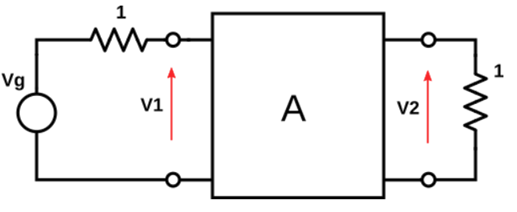

</div>

Diseñe el cuadripolo A para que se comporte como un filtro pasabajos Chebyshev de tercer orden, no disipativo y normalizado.

1. Obtenga la Impedancia de entrada.
2. Sintetice A como una red LC en escalera.
3. Simule la red en LTspice y verifique su respuesta en frecuencia.
   1. En este caso, el modulo de S21 debe ser igual al Cheby pasabajos de tercer orden.
   2. Y el modulo de S11 se calcula para $\omega = 0$, $\omega = \infty$.
4. Explicar el comportamiento de S11
5. Modificar la red para que la frecuencia de corte sea $\omega = 2 \, \pi [\frac{rad}{s}]$ y la resistencia del generador sea de $50 \, [\Omega]$.

In [2]:
from IPython.display import HTML

file = "./TS13_handwritten.pdf"
html = f"""
<div style="text-align:center;">
    <iframe src="{file}" width="900" height="600"></iframe>
</div>
"""
HTML(html)

In [3]:
s = symbols("s", complex=False)
w, eps = symbols("w \\varepsilon", real=True)

alpha_db = 1
eps_val = (10 ** (alpha_db / 10) - 1) ** 0.5

S12_mod_squared = 1 / (1 + eps**2 * (4 * (w) ** 3 - 3 * (w)) ** 2)
S11_mod_squared = 1 - S12_mod_squared

S11_mod_squared_sj = S11_mod_squared.subs(w, s / I).subs(eps, eps_val)

S11_mod_squared_sj_simpl = simplify(expand(S11_mod_squared_sj))
roots_num = nroots(Poly(S11_mod_squared_sj_simpl.as_numer_denom()[0], s), n=6)
roots_den = nroots(Poly(S11_mod_squared_sj_simpl.as_numer_denom()[1], s), n=6)

# Agarro los polos y ceros con parte real negativa o en el eje j
# Pero solo 3, porque es un filtro de orden 3
# Skippeo duplicados de 0
poles = set([r for r in roots_den if sp.re(r) < 0 or sp.re(r) == 0])
poles = list(poles)[:3]
zeros = set([r for r in roots_num if sp.re(r) < 0 or sp.re(r) == 0])
zeros = list(zeros)[:3]

Q = sp.expand(sp.prod([s - p for p in poles]))
P = sp.expand(sp.prod([s - z for z in zeros]))

S11 = sp.simplify(P / Q)

markdown_msg = f"""
### Expresiones Iniciales

$$ |S_{{12}}(j\omega)|^2 \Rightarrow \; \\text{{Cheby pasabajos orden 3}} \; \Rightarrow {sp.latex(S12_mod_squared)} $$

$$ \\varepsilon = {eps_val:.4f} \quad || \quad \\varepsilon^2 = {eps_val**2:.4f} \quad || \quad \\alpha_{{dB}} = {alpha_db} \; [dB] $$

$$ |S_{{11}}(j\omega)|^2 = 1 - |S_{{12}}(j\omega)|^2 = {sp.latex(S11_mod_squared)} $$

### Raíces de $|S_{{11}}(s=j\omega)|^2$

$$ |S_{{11}}(s=j\omega)|^2 = {sp.latex(S11_mod_squared_sj_simpl)} $$

$$ \\text{{Numerador raíces: }} {sp.latex(roots_num)} $$
$$ \\text{{Denominador raíces: }} {sp.latex(roots_den)} $$

### Polos y Ceros seleccionados

Se seleccionan los polos y ceros con parte real negativa o en el eje j, hasta completar 3 de cada uno (filtro de orden 3).

$$ \\text{{Polos seleccionados: }} {sp.latex(poles)} $$
$$ \\text{{Ceros seleccionados: }} {sp.latex(zeros)} $$

### Transferencia $S_{{11}}(s)$

$$ S_{{11}}(s) = {sp.latex(S11)} $$
"""
display(Markdown(markdown_msg))


### Expresiones Iniciales

$$ |S_{12}(j\omega)|^2 \Rightarrow \; \text{Cheby pasabajos orden 3} \; \Rightarrow \frac{1}{\varepsilon^{2} \left(4 w^{3} - 3 w\right)^{2} + 1} $$

$$ \varepsilon = 0.5088 \quad || \quad \varepsilon^2 = 0.2589 \quad || \quad \alpha_{dB} = 1 \; [dB] $$

$$ |S_{11}(j\omega)|^2 = 1 - |S_{12}(j\omega)|^2 = 1 - \frac{1}{\varepsilon^{2} \left(4 w^{3} - 3 w\right)^{2} + 1} $$

### Raíces de $|S_{11}(s=j\omega)|^2$

$$ |S_{11}(s=j\omega)|^2 = \frac{s^{2} \left(4.14280658870668 s^{4} + 6.21420988306002 s^{2} + 2.33032870614751\right)}{4.14280658870668 s^{6} + 6.21420988306002 s^{4} + 2.33032870614751 s^{2} - 1} $$

$$ \text{Numerador raíces: } \left[ 0, \  0, \  -0.000239896 - 0.866025 i, \  -0.000239896 + 0.866025 i, \  0.000239896 - 0.866025 i, \  0.000239896 + 0.866025 i\right] $$
$$ \text{Denominador raíces: } \left[ -0.494171, \  0.494171, \  -0.247085 - 0.965999 i, \  -0.247085 + 0.965999 i, \  0.247085 - 0.965999 i, \  0.247085 + 0.965999 i\right] $$

### Polos y Ceros seleccionados

Se seleccionan los polos y ceros con parte real negativa o en el eje j, hasta completar 3 de cada uno (filtro de orden 3).

$$ \text{Polos seleccionados: } \left[ -0.494171, \  -0.247085 + 0.965999 i, \  -0.247085 - 0.965999 i\right] $$
$$ \text{Ceros seleccionados: } \left[ 0, \  -0.000239896 + 0.866025 i, \  -0.000239896 - 0.866025 i\right] $$

### Transferencia $S_{11}(s)$

$$ S_{11}(s) = \frac{s \left(s^{2} + 0.000479792 s + 0.75\right)}{s^{3} + 0.988341 s^{2} + 1.23841 s + 0.491307} $$


In [4]:
Z1 = sp.simplify((1 + S11) / (1 - S11))

markdown_msg = f"""
### Expresiones Z1

$$ S_{{11}}(s) = \\cfrac{{Z_{1}(s) - 1}}{{Z_{1}(s) + 1}} $$

$$ \\Rightarrow \quad Z_{1}(s) = \\cfrac{{1 + S_{{11}}(s)}}{{1 - S_{{11}}(s)}} $$

### Inmitancia $Z_{1}(s)$

$$ Z_{{1}}(s) = {sp.latex(Z1)} $$
"""

display(Markdown(markdown_msg))


### Expresiones Z1

$$ S_{11}(s) = \cfrac{Z_1(s) - 1}{Z_1(s) + 1} $$

$$ \Rightarrow \quad Z_1(s) = \cfrac{1 + S_{11}(s)}{1 - S_{11}(s)} $$

### Inmitancia $Z_1(s)$

$$ Z_{1}(s) = \frac{2.0 s^{3} + 0.988821 s^{2} + 1.98841 s + 0.491307}{0.987862 s^{2} + 0.488409 s + 0.491307} $$


In [5]:
markdown_msg = f"""
### Síntesis por división sucesiva de polinomios

"""

components = {}

# Obtengo la división entre numerador y denominador
num, den = Z1.as_numer_denom()
q, r = sp.div(sp.Poly(num, s), sp.Poly(den, s))
Yrem1 = sp.simplify(sp.Poly(den, s).as_expr() / sp.Poly(r, s).as_expr())

msg1 = f"""
$$ \\textbf{{Componente en serie:}} \quad {sp.latex(q.as_expr())} $$

$$ Y_{{rem1}}(s) = {sp.latex(Yrem1)} $$
"""

components["L1"] = q.all_coeffs()[0]

markdown_msg += msg1

# Segunda etapa
num, den = Yrem1.as_numer_denom()
q, r = sp.div(sp.Poly(num, s), sp.Poly(den, s))
Zrem2 = sp.simplify(sp.Poly(den, s).as_expr() / sp.Poly(r, s).as_expr())

msg2 = f"""
$$ \\textbf{{Componente en paralelo:}} \quad {sp.latex(q.as_expr())} $$

$$ Z_{{rem2}}(s) = {sp.latex(Zrem2)}$$
"""

components["C2"] = 1 / q.all_coeffs()[0]

markdown_msg += msg2

# Tercera etapa
num, den = Zrem2.as_numer_denom()
q, r = sp.div(sp.Poly(num, s), sp.Poly(den, s))
Yrem3 = sp.simplify(sp.Poly(r, s).as_expr() / sp.Poly(den, s).as_expr())

msg3 = f"""
$$ \\textbf{{Componente en serie:}} \quad {sp.latex(q.as_expr())} $$

$$ Y_{{rem3}}(s) = {sp.latex(Yrem3)} $$
"""

components["L3"] = q.all_coeffs()[0]

markdown_msg += msg3

display(Markdown(markdown_msg))


### Síntesis por división sucesiva de polinomios


$$ \textbf{Componente en serie:} \quad 2.02458 s - 4.82696 \cdot 10^{-7} $$

$$ Y_{rem1}(s) = \frac{0.987862 s^{2} + 0.488409 s + 0.491307}{0.993722 s + 0.491307} $$

$$ \textbf{Componente en paralelo:} \quad 0.994102 s $$

$$ Z_{rem2}(s) = 2.02261 s + 1.0$$

$$ \textbf{Componente en serie:} \quad 2.02261 s + 1.0 $$

$$ Y_{rem3}(s) = 0 $$


## Simulación LTspice

<div align=center>

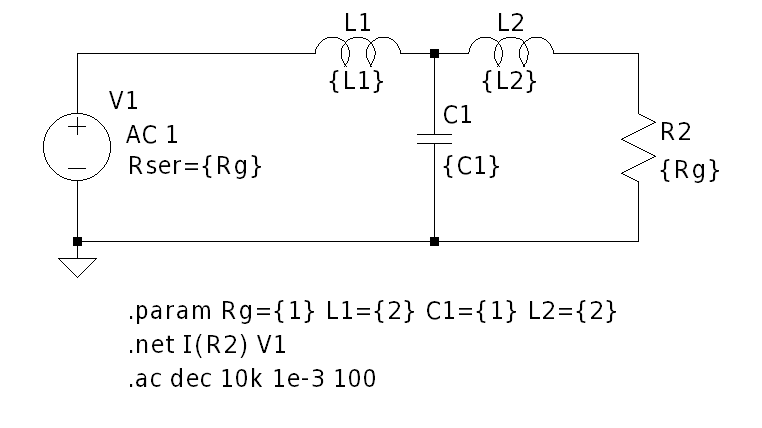

</div>

<a href="./TS13.asc" download="TS13.asc">Descargar TS13.asc</a>

<a href="./TS13.plt" download="TS13.plt">Descargar TS13.plt</a>

<div align=center>

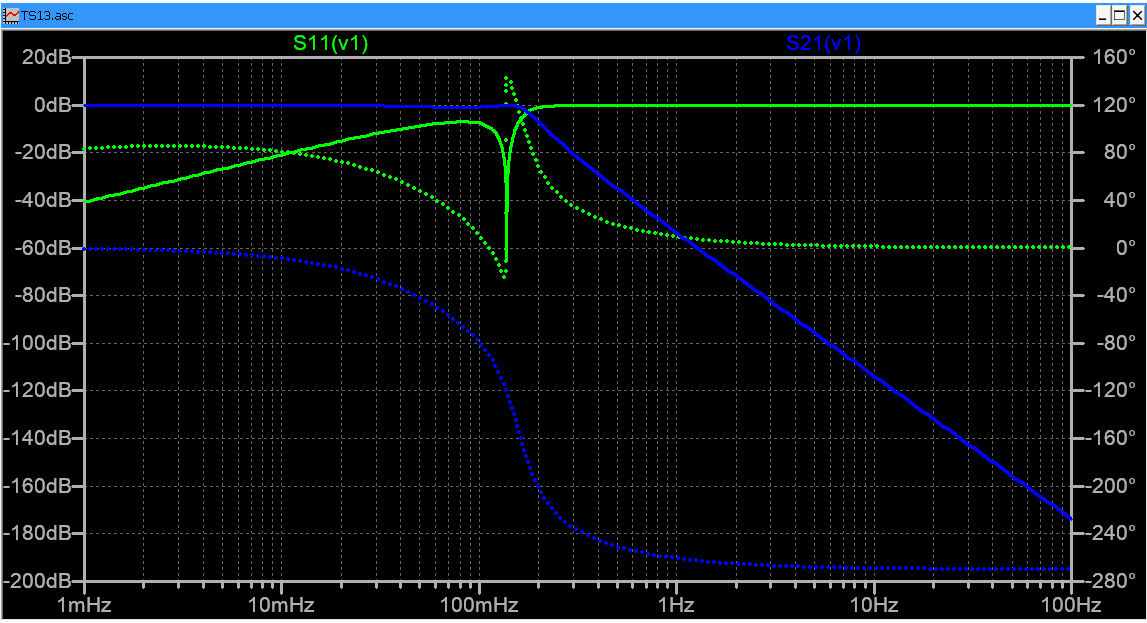

</div>

In [6]:
S11_at_0 = S11.limit(s, 0)
# Agrego un pequeño offset para evitar log(0)
S11_at_0_in_db = 10 * sp.log(sp.Abs(S11_at_0 + 1e-15), 10)

S11_at_oo = S11.limit(s, sp.oo)
S11_at_oo_in_db = 10 * sp.log(sp.Abs(S11_at_oo), 10)

markdown_msg = f"""
### Análisis de $S_{{11}}$ en $s=0$ y $s=\\infty$

$$ S_{{11}}(0) = {sp.latex(S11_at_0)} \quad \Rightarrow \quad {sp.latex(S11_at_0_in_db.round(2))} \; [dB] $$

$$ S_{{11}}(\\infty) = {sp.latex(S11_at_oo)} \quad \Rightarrow \quad {sp.latex(S11_at_oo_in_db)} \; [dB] $$

### Conclusión
En $s=0$, la reflexión es baja (aprox. -150 dB), indicando buena adaptación en bajas frecuencias. En $s=\\infty$, la reflexión es alta (0 dB), indicando mala adaptación en altas frecuencias.

Al observar el gráfico en Ltspice, se confirma que el filtro presenta baja reflexión en la banda pasante y alta reflexión en la banda de rechazo, coherente con el análisis teórico.
Además, la respuesta en frecuencia de $S_{{21}}$ muestra las características típicas de un filtro Chebyshev de orden 3, con ondulaciones en la banda pasante y una caída pronunciada en la banda de rechazo.
Un detalle importante es que cerca de la frecuencia de corte, $S_{{11}}$ se adapta muy bien pero el ancho de banda en el cual la reflexión es baja es relativamente estrecho, lo que es típico en filtros Chebyshev debido a las ondulaciones en la banda pasante.
"""

display(Markdown(markdown_msg))


### Análisis de $S_{11}$ en $s=0$ y $s=\infty$

$$ S_{11}(0) = 0 \quad \Rightarrow \quad -150.0 \; [dB] $$

$$ S_{11}(\infty) = 1 \quad \Rightarrow \quad 0 \; [dB] $$

### Conclusión
En $s=0$, la reflexión es baja (aprox. -150 dB), indicando buena adaptación en bajas frecuencias. En $s=\infty$, la reflexión es alta (0 dB), indicando mala adaptación en altas frecuencias.

Al observar el gráfico en Ltspice, se confirma que el filtro presenta baja reflexión en la banda pasante y alta reflexión en la banda de rechazo, coherente con el análisis teórico.
Además, la respuesta en frecuencia de $S_{21}$ muestra las características típicas de un filtro Chebyshev de orden 3, con ondulaciones en la banda pasante y una caída pronunciada en la banda de rechazo.
Un detalle importante es que cerca de la frecuencia de corte, $S_{11}$ se adapta muy bien pero el ancho de banda en el cual la reflexión es baja es relativamente estrecho, lo que es típico en filtros Chebyshev debido a las ondulaciones en la banda pasante.


In [7]:
# Modificaciones para que la frecuencia de corte sea 1Mhz y Rg=50ohm
f_corte = 1e6  # 1 MHz
w_corte = 2 * np.pi * f_corte

Rg = 50  # Ohm

normalized_components = {}
for key, value in components.items():
    if key.startswith("L"):
        normalized_value = value / w_corte * Rg
    elif key.startswith("C"):
        normalized_value = value / (w_corte * Rg)
    normalized_components[key] = normalized_value

markdown_msg = f"""### Componentes Originales\n\n"""
for key, value in components.items():
    markdown_msg += f"$$ {key} = {value:.2f} $$\n\n"

markdown_msg += "### Componentes Desnormalizados para $f_{{corte}} = 1[MHz]$ y $R_{{g}} = 50 \\; \\Omega$\n\n"
for key, value in normalized_components.items():
    markdown_msg += f"$$ {key} = {value:.2e} $$\n\n"
markdown_msg += """
Se asume $R_L = R_g = 50 \\; [\\Omega]$.
"""
display(Markdown(markdown_msg))

### Componentes Originales

$$ L1 = 2.02 $$

$$ C2 = 1.01 $$

$$ L3 = 2.02 $$

### Componentes Desnormalizados para $f_{{corte}} = 1[MHz]$ y $R_{{g}} = 50 \; \Omega$

$$ L1 = 1.61e-5 $$

$$ C2 = 3.20e-9 $$

$$ L3 = 1.61e-5 $$


Se asume $R_L = R_g = 50 \; [\Omega]$.


## Simulación LTspice con Componentes Desnormalizados

<div align=center>

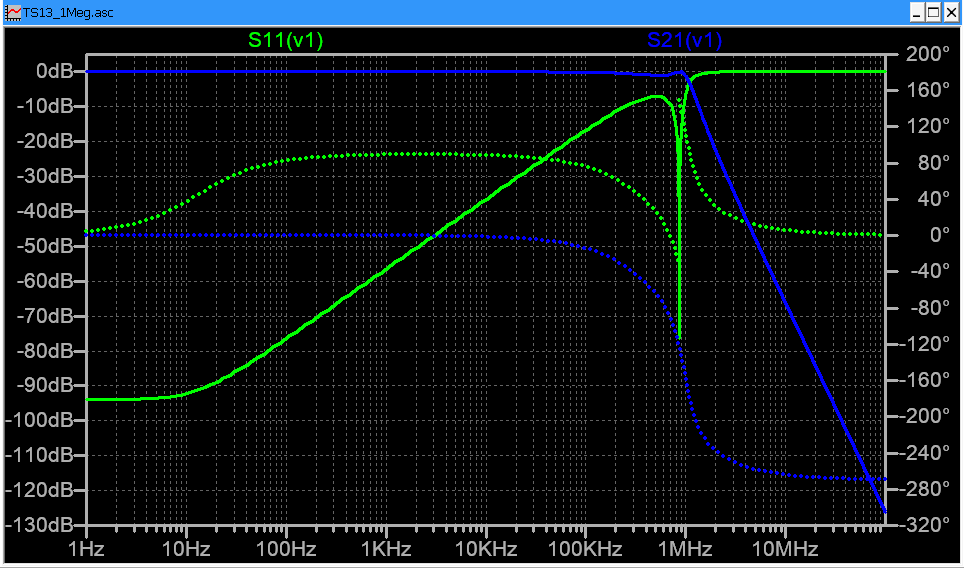

</div>

<a href="./TS13_1Meg.asc" download="TS13_1Meg.asc">Descargar TS13_1Meg.asc</a>

<a href="./TS13_1Meg.plt" download="TS13_1Meg.plt">Descargar TS13_1Meg.plt</a>